In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Defence thesis/Pre Defense /questionnaire.csv")
df

,Gender,University,Age,Type_of_Residence,Family_Size,Parental_Status,Mother_Education,Father_Education,Mother_Job,Father_Job,...,Internet_At_Home,In_Relationship,Relationship_Satisfaction,Family_Relationships,Overall_Health,Bullying_Frequency,PartTime_Job,Absences_Semester,Average_CGPA,CGPA_Satisfaction
0,M,DIU,23.0,U,GT3,A,1,0,Housewife,Farmer,...,Yes,No,NaN,5.0,5.0,Never,No,2.0,3.28,3.0
1,M,DIU,24.0,R,GT3,A,3,4,Housewife,Teacher,...,Yes,No,NaN,5.0,4.0,Rarely,No,0.0,3.71,4.0
2,F,DIU,19.0,R,GT3,A,2,2,Housewife,Farmer,...,Yes,No,NaN,1.0,3.0,Never,No,2.0,NaN,3.0
3,M,DIU,24.0,U,GT3,A,1,3,Housewife,Govt Job,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,M,DIU,23.0,U,GT3,A,4,4,Housewife,Businessman,...,Yes,Yes,4.0,5.0,3.0,Never,Yes,NaN,3.49,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
494,M,DIU,24.0,R,GT3,A,4,4,Housewife,Govt job,...,Yes,No,NaN,5.0,2.0,Rarely,No,2.0,3.58,1.0
495,M,DIU,25.0,R,LE3,A,4,4,Teacher,Teacher,...,Yes,No,NaN,5.0,3.0,Never,No,5.0,3.12,3.0
496,M,DIU,25.0,U,GT3,T,4,4,Housewife,Dead,...,Yes,No,5.0,5.0,1.0,Always,No,4.0,NaN,3.0
497,M,JKKNIU,19.0,R,GT3,A,0,0,Housewife,Farmer,...,No,No,1.0,5.0,3.0,Never,No,2.0,NaN,4.0


In [ ]:
df_clean = df.copy()
numeric_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns.tolist()
object_cols = df_clean.select_dtypes(include=['object']).columns.tolist()

for col in object_cols:
   df_clean[col] = df_clean[col].astype(str).str.strip()

for col in object_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='ignore')

df = df_clean

/tmp/ipython-input-1523556729.py:9: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_clean[col] = pd.to_numeric(df_clean[col], errors='ignore')


In [ ]:
df.columns

Index(['Gender', 'University', 'Age', 'Type_of_Residence', 'Family_Size',
       'Parental_Status', 'Mother_Education', 'Father_Education', 'Mother_Job',
       'Father_Job', 'Primary_Guardian', 'Motivation_Level',
       'University_Selection_Method', 'University_Choice_Reason',
       'Program_Choice_Personal', 'Program_Satisfaction_Level',
       'Living_Arrangement', 'Travel_Time_', 'Study_Hours_Per_Week',
       'Failed_Classes', 'Num_Failed_Classes', 'Extra_Support_University',
       'Changed_Major', 'Reason_Changed_Major', 'Considered_Dropout',
       'Reason_Considered_Dropout', 'Adjustment_Issues',
       'Adjustment_Difficulty', 'Stress_Frequency', 'Made_Friends',
       'Hangout_Frequency', 'Social_Activity_Frequency',
       'Extracurricular_Participation', 'Free_Time', 'Classmate_Cooperation',
       'Mentor_Support', 'Internet_At_Home', 'In_Relationship',
       'Relationship_Satisfaction', 'Family_Relationships', 'Overall_Health',
       'Bullying_Frequency', 'PartTime_

In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
Num_Failed_Classes,231
Relationship_Satisfaction,207
Absences_Semester,7
Travel_Time_,6
Age,4
CGPA_Satisfaction,2
Adjustment_Difficulty,1
Study_Hours_Per_Week,1
Hangout_Frequency,1
Overall_Health,1


In [ ]:
df.loc[df['Considered_Dropout'] == 'No', 'Reason_Considered_Dropout'] = None
df.loc[df['In_Relationship'] == 'No', 'Relationship_Satisfaction'] = None
df.loc[df['Changed_Major'] == 'No', 'Reason_Changed_Major'] = None
df.loc[df['Failed_Classes'] == 'No', 'Num_Failed_Classes'] = 0

In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
Reason_Changed_Major,435
Reason_Considered_Dropout,394
Relationship_Satisfaction,336
Num_Failed_Classes,9
Absences_Semester,7
Travel_Time_,6
Age,4
CGPA_Satisfaction,2
Study_Hours_Per_Week,1
Hangout_Frequency,1


In [ ]:
df.dtypes

,0
Gender,object
University,object
Age,float64
Type_of_Residence,object
Family_Size,object
Parental_Status,object
Mother_Education,int64
Father_Education,int64
Mother_Job,object
Father_Job,object


In [ ]:
cols = [
    'Reason_Changed_Major',
    'Reason_Considered_Dropout',
    'Relationship_Satisfaction'
]

for col in df.columns:

    if col not in cols:

        if pd.api.types.is_numeric_dtype(df[col]):
            median_val = df[col].median()
            df[col] = df[col].fillna(median_val)

        elif pd.api.types.is_object_dtype(df[col]):
            mode_val = df[col].mode(dropna=True)[0]
            df[col] = df[col].fillna(mode_val)

    else:
        df[col] = df[col].fillna('Not_Applicable')

In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
Gender,0
University,0
Age,0
Type_of_Residence,0
Family_Size,0
Parental_Status,0
Mother_Education,0
Father_Education,0
Mother_Job,0
Father_Job,0


In [ ]:
with pd.option_context('display.max_rows', None):
    print(df[['Reason_Changed_Major', 'Reason_Considered_Dropout', 'Relationship_Satisfaction']])

                             Reason_Changed_Major  \
0                                  Not_Applicable   
1                                  Not_Applicable   
2                                  Not_Applicable   
3                                             nan   
4                                  Not_Applicable   
5                                  Not_Applicable   
6                                  Not_Applicable   
7                                  Not_Applicable   
8                                  Not_Applicable   
9                                  Not_Applicable   
10         Lack of interest in the original major   
11                                 Not_Applicable   
12                                 Not_Applicable   
13                                 Not_Applicable   
14                                 Not_Applicable   
15                                 Not_Applicable   
16                                 Not_Applicable   
17                                 Not_Applica

In [ ]:
df['Relationship_Satisfaction'] = df['Relationship_Satisfaction'].replace('Not_Applicable', 0)
df['Relationship_Satisfaction'] = df['Relationship_Satisfaction'].astype(float)

/tmp/ipython-input-48760170.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Relationship_Satisfaction'] = df['Relationship_Satisfaction'].replace('Not_Applicable', 0)


In [ ]:
df = df.drop(['University','Reason_Considered_Dropout'], axis=1)

In [ ]:
df['Average_CGPA'].dtype

dtype('O')

In [ ]:
df['Average_CGPA'] = pd.to_numeric(df['Average_CGPA'], errors='coerce')
df['Average_CGPA'] = df['Average_CGPA'].fillna(df['Average_CGPA'].median())
df['Average_CGPA'].dtype

dtype('float64')

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
import shap

In [ ]:
X = df.drop(['Considered_Dropout'], axis=1)
y = df['Considered_Dropout']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
nominal_cols = ['Gender','Type_of_Residence', 'Family_Size', 'Parental_Status',
                'Mother_Job', 'Father_Job', 'Primary_Guardian', 'University_Selection_Method',
                'University_Choice_Reason', 'Program_Choice_Personal', 'Living_Arrangement',
                'Failed_Classes', 'Extra_Support_University', 'Changed_Major', 'Reason_Changed_Major',
                'Adjustment_Issues', 'Stress_Frequency', 'Made_Friends', 'Social_Activity_Frequency',
                'Extracurricular_Participation', 'Internet_At_Home', 'In_Relationship',
                'Bullying_Frequency', 'PartTime_Job']

numeric_cols = ['Age','Num_Failed_Classes','Travel_Time_','Absences_Semester','Average_CGPA']

ordinal_cols = ['Mother_Education','Father_Education','Motivation_Level','Program_Satisfaction_Level',
                'Study_Hours_Per_Week','Adjustment_Difficulty','Hangout_Frequency','Free_Time',
                'Classmate_Cooperation','Mentor_Support','Family_Relationships','Relationship_Satisfaction',
                'Overall_Health','CGPA_Satisfaction']

In [ ]:
def outliers(X):
    X = np.array(X, dtype=float)
    X_out = X.copy()
    for i in range(X.shape[1]):
        col = X[:, i]
        Q1 = np.percentile(col, 25)
        Q3 = np.percentile(col, 75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        median = np.median(col)
        col = np.where(col < lower, median, col)
        col = np.where(col > upper, median, col)
        X_out[:, i] = col
    return X_out

outlier_transformer = FunctionTransformer(outliers, validate=True)

In [ ]:
from sklearn.preprocessing import OrdinalEncoder


num_pipeline = Pipeline([
    ('outlier', outlier_transformer),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer([
    ('nom', OneHotEncoder(handle_unknown='ignore'), nominal_cols),
    ('num', num_pipeline, numeric_cols),
    ('ord', OrdinalEncoder(), ordinal_cols)
])
preprocessor.fit(X_train)

ohe_cols = preprocessor.named_transformers_['nom'].get_feature_names_out().shape[0]
num_cols = len(numeric_cols)
ord_cols = len(ordinal_cols)

categorical_indices = (
    list(range(0, ohe_cols)) +
    list(range(ohe_cols + num_cols, ohe_cols + num_cols + ord_cols))
)

X_train_trans = preprocessor.transform(X_train)
X_test_trans = preprocessor.transform(X_test)


if hasattr(X_train_trans, "toarray"):
    X_train_trans = X_train_trans.toarray()
    X_test_trans = X_test_trans.toarray()


ohe = preprocessor.named_transformers_['nom']
ohe_features = ohe.get_feature_names_out(nominal_cols)
feature_names = list(ohe_features) + list(numeric_cols) + list(ordinal_cols)


X_train_trans = pd.DataFrame(X_train_trans, columns=feature_names)
X_test_trans = pd.DataFrame(X_test_trans, columns=feature_names)


nan_cols = [col for col in X_train_trans.columns if col.endswith('_nan')]
X_train_trans = X_train_trans.drop(columns=nan_cols)
X_test_trans = X_test_trans.drop(columns=nan_cols)


feature_names = X_train_trans.columns.tolist()

In [ ]:
print(y_train.value_counts())

Considered_Dropout
No     308
Yes     91
Name: count, dtype: int64


In [ ]:
ohe_features = ohe.get_feature_names_out(nominal_cols)
categorical_indices = [i for i, f in enumerate(feature_names) if f in ohe_features]


if hasattr(X_train_trans, "toarray"):
    X_train_trans = X_train_trans.toarray()
    X_test_trans = X_test_trans.toarray()


from imblearn.over_sampling import SMOTENC

sm = SMOTENC(
    categorical_features=categorical_indices,
    random_state=42
)

X_train_bal, y_train_bal = sm.fit_resample(X_train_trans, y_train)

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.5 MB/s eta 0:00:00


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train_bal)
y_test_enc  = le.transform(y_test)

print("Shapes:", X_train_bal.shape, X_test_trans.shape)
print("Label classes:", list(le.classes_))

Shapes: (616, 169) (100, 169)
Label classes: ['No', 'Yes']


In [ ]:
from sklearn.feature_selection import RFE
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import pandas as pd


rfe_models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(
        eval_metric='logloss',
        use_label_encoder=False,
        random_state=42,
        n_estimators=200
    ),
    "CatBoost": CatBoostClassifier(
        verbose=0,
        random_state=42,
        iterations=200
    )
}

X_train_bal_df = pd.DataFrame(X_train_bal, columns=feature_names)

rfe_selected_features = {}


for name, model in rfe_models.items():
    print(f"\nRunning RFE for {name}...")
    rfe = RFE(estimator=model, n_features_to_select=20, step=1)

    try:
        rfe.fit(X_train_bal_df, y_train_enc)
        feature_support = pd.Series(rfe.support_, index=feature_names)
        top_features = feature_support[feature_support].index.tolist()
        rfe_selected_features[name] = top_features

        print(f"Top 20 RFE features for {name}:")
        print(top_features)

    except Exception as e:
        print(f"RFE failed for {name}: {e}")


Running RFE for Decision Tree...
Top 20 RFE features for Decision Tree:
['Type_of_Residence_U', 'Living_Arrangement_In university halls', 'Living_Arrangement_Private accommodation', 'Adjustment_Issues_Difficulty making friends', 'Adjustment_Issues_No major issues', 'Stress_Frequency_Often', 'Stress_Frequency_Rarely', 'PartTime_Job_Yes', 'Age', 'Travel_Time_', 'Average_CGPA', 'Father_Education', 'Motivation_Level', 'Program_Satisfaction_Level', 'Adjustment_Difficulty', 'Free_Time', 'Classmate_Cooperation', 'Mentor_Support', 'Relationship_Satisfaction', 'Overall_Health']

Running RFE for Random Forest...
Top 20 RFE features for Random Forest:
['Gender_F', 'Type_of_Residence_R', 'Age', 'Travel_Time_', 'Absences_Semester', 'Average_CGPA', 'Mother_Education', 'Father_Education', 'Motivation_Level', 'Program_Satisfaction_Level', 'Study_Hours_Per_Week', 'Adjustment_Difficulty', 'Hangout_Frequency', 'Free_Time', 'Classmate_Cooperation', 'Mentor_Support', 'Family_Relationships', 'Relationship_

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [16:21:00] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [16:21:00] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [16:21:01] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [16:21:01] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [16:21:01] WARNING: /w

Top 20 RFE features for XGBoost:
['Gender_F', 'Type_of_Residence_R', 'Father_Job_Teacher', 'Primary_Guardian_Father', 'Living_Arrangement_Private accommodation', 'Failed_Classes_No', 'Reason_Changed_Major_Better career opportunities in the new major', 'Adjustment_Issues_No major issues', 'Stress_Frequency_Often', 'Stress_Frequency_Rarely', 'Social_Activity_Frequency_Rarely', 'PartTime_Job_No', 'Father_Education', 'Program_Satisfaction_Level', 'Adjustment_Difficulty', 'Hangout_Frequency', 'Classmate_Cooperation', 'Family_Relationships', 'Relationship_Satisfaction', 'Overall_Health']

Running RFE for CatBoost...
Top 20 RFE features for CatBoost:
['Gender_M', 'Type_of_Residence_U', 'Age', 'Travel_Time_', 'Absences_Semester', 'Average_CGPA', 'Mother_Education', 'Father_Education', 'Motivation_Level', 'Program_Satisfaction_Level', 'Study_Hours_Per_Week', 'Adjustment_Difficulty', 'Hangout_Frequency', 'Free_Time', 'Classmate_Cooperation', 'Mentor_Support', 'Family_Relationships', 'Relationshi

In [ ]:
# Convert results to DataFrame for comparison
rfe_summary_df = pd.DataFrame(dict([(k, pd.Series(v)) for k, v in rfe_selected_features.items()]))

print("\n===== Summary of Top 20 RFE Features per Model =====")
print(rfe_summary_df)


===== Summary of Top 20 RFE Features per Model =====
                                  Decision Tree               Random Forest  \
0                           Type_of_Residence_U                    Gender_F   
1        Living_Arrangement_In university halls         Type_of_Residence_R   
2      Living_Arrangement_Private accommodation                         Age   
3   Adjustment_Issues_Difficulty making friends                Travel_Time_   
4             Adjustment_Issues_No major issues           Absences_Semester   
5                        Stress_Frequency_Often                Average_CGPA   
6                       Stress_Frequency_Rarely            Mother_Education   
7                              PartTime_Job_Yes            Father_Education   
8                                           Age            Motivation_Level   
9                                  Travel_Time_  Program_Satisfaction_Level   
10                                 Average_CGPA        Study_Hours_Per_Week  

In [ ]:
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# Ensure your balanced data is a DataFrame
X_train_bal_df = pd.DataFrame(X_train_bal, columns=feature_names)
X_test_df = pd.DataFrame(X_test_trans, columns=feature_names)

# Use the same models that you used earlier (or define again)
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', verbosity=0, random_state=42, n_estimators=200),
    "CatBoost": CatBoostClassifier(verbose=0, random_state=42, iterations=200)
}

print("\n===== Model Training with RFE-Selected Features =====\n")
rfe_train_results = {}

for name, model in models.items():
    print(f"\n🔹 Training {name} using its RFE-selected features...")

    # Get the top RFE features for this model
    selected_feats = rfe_selected_features.get(name)
    if not selected_feats:
        print(f"No RFE features found for {name}, skipping...")
        continue

    # Prepare data subsets
    X_train_sel = X_train_bal_df[selected_feats]
    X_test_sel = X_test_df[selected_feats]

    # Train and evaluate
    model.fit(X_train_sel, y_train_enc)
    y_pred = model.predict(X_test_sel)
    acc = accuracy_score(y_test_enc, y_pred)

    rfe_train_results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")
    print(classification_report(y_test_enc, y_pred, zero_division=0))



===== Model Training with RFE-Selected Features =====


🔹 Training Decision Tree using its RFE-selected features...
Decision Tree Accuracy: 0.7700
              precision    recall  f1-score   support

           0       0.96      0.77      0.85        86
           1       0.35      0.79      0.49        14

    accuracy                           0.77       100
   macro avg       0.66      0.78      0.67       100
weighted avg       0.87      0.77      0.80       100


🔹 Training Random Forest using its RFE-selected features...
Random Forest Accuracy: 0.8600
              precision    recall  f1-score   support

           0       0.89      0.95      0.92        86
           1       0.50      0.29      0.36        14

    accuracy                           0.86       100
   macro avg       0.70      0.62      0.64       100
weighted avg       0.84      0.86      0.84       100


🔹 Training XGBoost using its RFE-selected features...
XGBoost Accuracy: 0.8200
              precision   

In [ ]:
# Convert results to DataFrame for easy comparison
acc_df = pd.DataFrame(list(rfe_train_results.items()), columns=['Model', 'Accuracy'])
print("\n===== Accuracy Summary (RFE-selected features) =====\n")
print(acc_df)


===== Accuracy Summary (RFE-selected features) =====

           Model  Accuracy
0  Decision Tree      0.77
1  Random Forest      0.86
2        XGBoost      0.82
3       CatBoost      0.83


In [ ]:
# Convert feature lists to sets
feature_sets = [set(feats) for feats in rfe_selected_features.values() if feats]

# Find intersection across all models
common_rfe_features = set.intersection(*feature_sets)

print("\n===== Common RFE Features Across All Models =====")
print(list(common_rfe_features))


===== Common RFE Features Across All Models =====
['Relationship_Satisfaction', 'Adjustment_Difficulty', 'Program_Satisfaction_Level', 'Overall_Health', 'Classmate_Cooperation', 'Father_Education']


In [ ]:
common_features = list(common_rfe_features)

X_train_common = X_train_bal_df[common_features]
X_test_common = X_test_df[common_features]

for name, model in models.items():
    print(f"\nTraining {name} on common RFE features...")
    model.fit(X_train_common, y_train_enc)
    y_pred = model.predict(X_test_common)
    acc = accuracy_score(y_test_enc, y_pred)
    print(f"{name} Accuracy common features: {acc:.4f}")



Training Decision Tree on common RFE features...
Decision Tree Accuracy common features: 0.7000

Training Random Forest on common RFE features...
Random Forest Accuracy common features: 0.7900

Training XGBoost on common RFE features...
XGBoost Accuracy common features: 0.7600

Training CatBoost on common RFE features...
CatBoost Accuracy common features: 0.7900


Processing SHAP for Decision Tree...
Processing SHAP for Random Forest...


 95%|=================== | 190/200 [00:15<00:00]       

Processing SHAP for XGBoost...
Processing SHAP for CatBoost...


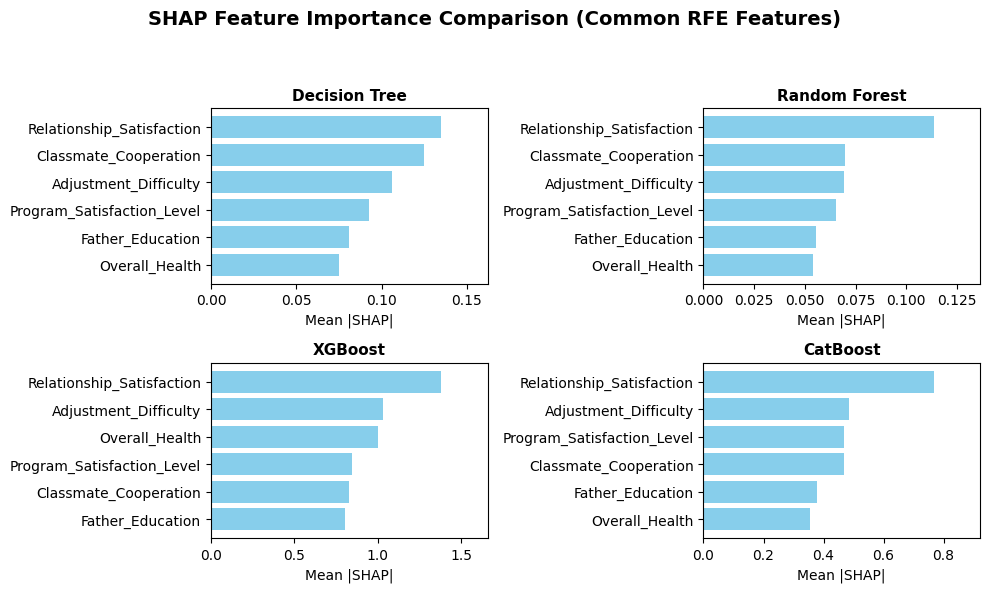

In [ ]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

fig, axes = plt.subplots(2, 2, figsize=(10, 6))  # 2 rows, 2 columns
fig.suptitle("SHAP Feature Importance Comparison (Common RFE Features)", fontsize=14, fontweight='bold')

axes = axes.flatten()  # flatten 2x2 array for easy indexing

for i, (name, model) in enumerate(models.items()):
    print(f"Processing SHAP for {name}...")
    try:
        explainer = shap.Explainer(model, X_train_common)
    except Exception:
        explainer = shap.TreeExplainer(model)

    shap_values = explainer(X_test_common)

    # Handle multi-class or list outputs safely
    shap_array = shap_values.values
    if shap_array.ndim == 3:
        shap_array = shap_array[:, :, 0]
    elif isinstance(shap_array, list):
        shap_array = shap_array[0]

    mean_abs_shap = np.mean(np.abs(shap_array), axis=0)

    importance = pd.DataFrame({
        'Feature': common_features,
        'Mean_SHAP': mean_abs_shap.flatten()
    }).sort_values(by='Mean_SHAP', ascending=True)

    # Plot horizontal bar chart
    axes[i].barh(importance['Feature'], importance['Mean_SHAP'], color='skyblue')
    axes[i].set_title(name, fontsize=11, fontweight='bold')
    axes[i].set_xlabel("Mean |SHAP|")
    axes[i].set_xlim(0, max(mean_abs_shap) * 1.2)

# Remove any unused subplots if <4 models
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

In [ ]:
if 'rfe_selected_features' not in globals() or not isinstance(rfe_selected_features, dict):
    raise NameError("rfe_selected_features (dict) not found. Make sure your RFE loop populated it.")
if len(rfe_selected_features) == 0:
    raise ValueError("rfe_selected_features is empty. Run the RFE cell that fills it before this analysis.")

model_names = list(rfe_selected_features.keys())

feature_universe = set()
for feats in rfe_selected_features.values():
    if feats:
        feature_universe.update(feats)

feature_list = sorted(feature_universe)

data = {}
for m in model_names:
    sel_set = set(rfe_selected_features.get(m, []))
    data[m] = [1 if f in sel_set else 0 for f in feature_list]

df_importance = pd.DataFrame(data, index=feature_list)
df_importance.index.name = "Feature"

# Mean "selection score" across models (higher = selected by more models)
df_importance['mean_rank'] = df_importance[model_names].mean(axis=1)

print("===== FEATURE IMPORTANCE (RFE Selection Matrix) =====\n")
print(df_importance.head(20))

===== FEATURE IMPORTANCE (RFE Selection Matrix) =====

                                             Decision Tree  Random Forest  \
Feature                                                                     
Absences_Semester                                        0              1   
Adjustment_Difficulty                                    1              1   
Adjustment_Issues_Difficulty making friends              1              0   
Adjustment_Issues_No major issues                        1              0   
Age                                                      1              1   
Average_CGPA                                             1              1   
CGPA_Satisfaction                                        0              1   
Classmate_Cooperation                                    1              1   
Failed_Classes_No                                        0              0   
Family_Relationships                                     0              1   
Father_Education     

In [ ]:
print("\n===== DESCRIPTIVE STATS (Selection Indicators) =====\n")
desc_stats = df_importance[model_names].describe().T
print(desc_stats)


===== DESCRIPTIVE STATS (Selection Indicators) =====

               count      mean       std  min  25%  50%  75%  max
Decision Tree   35.0  0.571429  0.502096  0.0  0.0  1.0  1.0  1.0
Random Forest   35.0  0.571429  0.502096  0.0  0.0  1.0  1.0  1.0
XGBoost         35.0  0.571429  0.502096  0.0  0.0  1.0  1.0  1.0
CatBoost        35.0  0.571429  0.502096  0.0  0.0  1.0  1.0  1.0


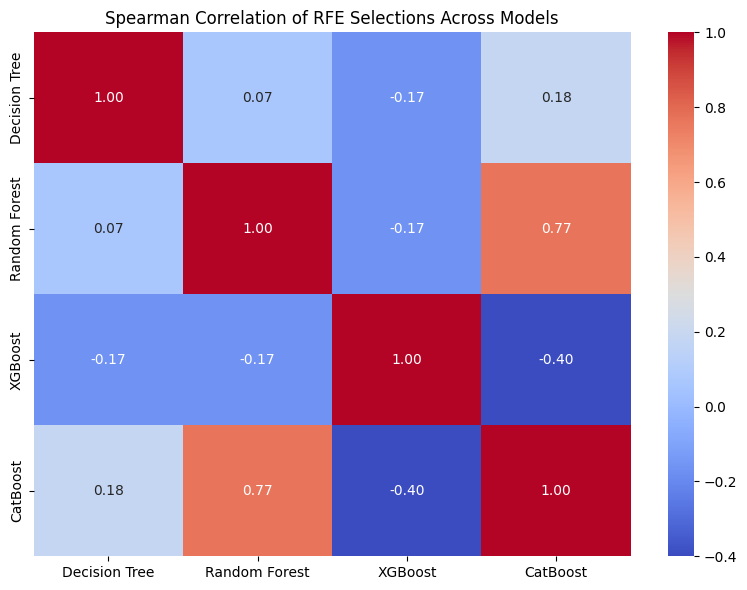

In [ ]:
correlation_matrix = df_importance[model_names].corr(method='spearman')

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Spearman Correlation of RFE Selections Across Models")
plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import spearmanr, kendalltau

print("\n===== Rank Correlation Between Models (RFE Selections) =====")
for i, m1 in enumerate(model_names):
    for m2 in model_names[i+1:]:
        rho, _ = spearmanr(df_importance[m1], df_importance[m2])
        tau, _ = kendalltau(df_importance[m1], df_importance[m2])
        print(f"{m1} vs {m2}: Spearman={rho:.3f}, Kendall={tau:.3f}")

# --- Top Features Visualization ---
# Here "top" = most commonly selected across models (highest mean_rank)
print("\n===== TOP COMMON FEATURES (by selection frequency) =====\n")
top_features = df_importance.sort_values('mean_rank', ascending=False).head(20)
print(top_features)


===== Rank Correlation Between Models (RFE Selections) =====
Decision Tree vs Random Forest: Spearman=0.067, Kendall=0.067
Decision Tree vs XGBoost: Spearman=-0.167, Kendall=-0.167
Decision Tree vs CatBoost: Spearman=0.183, Kendall=0.183
Random Forest vs XGBoost: Spearman=-0.167, Kendall=-0.167
Random Forest vs CatBoost: Spearman=0.767, Kendall=0.767
XGBoost vs CatBoost: Spearman=-0.400, Kendall=-0.400

===== TOP COMMON FEATURES (by selection frequency) =====

                                          Decision Tree  Random Forest  \
Feature                                                                  
Adjustment_Difficulty                                 1              1   
Classmate_Cooperation                                 1              1   
Father_Education                                      1              1   
Relationship_Satisfaction                             1              1   
Overall_Health                                        1              1   
Program_Satisfac

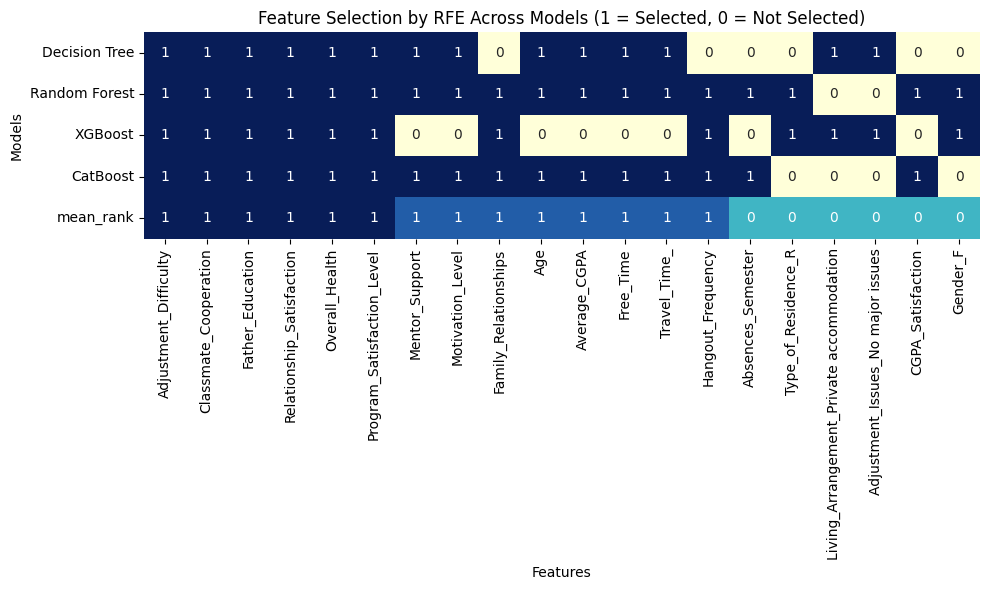

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(top_features.T, cmap="YlGnBu", cbar=False, annot=True, fmt=".0f")
plt.title("Feature Selection by RFE Across Models (1 = Selected, 0 = Not Selected)")
plt.xlabel("Features")
plt.ylabel("Models")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
rank_summary = pd.DataFrame({
    'Feature': df_importance.index,
    'Mean Selection (0-1)': df_importance['mean_rank'],
    'Selection StdDev': df_importance[model_names].std(axis=1)
}).sort_values('Mean Selection (0-1)', ascending=False).reset_index(drop=True)

print("\n===== Feature Selection Summary =====\n")
print(rank_summary.head(20))


===== Feature Selection Summary =====

                                     Feature  Mean Selection (0-1)  \
0                      Adjustment_Difficulty                  1.00   
1                      Classmate_Cooperation                  1.00   
2                           Father_Education                  1.00   
3                  Relationship_Satisfaction                  1.00   
4                             Overall_Health                  1.00   
5                 Program_Satisfaction_Level                  1.00   
6                             Mentor_Support                  0.75   
7                           Motivation_Level                  0.75   
8                       Family_Relationships                  0.75   
9                                        Age                  0.75   
10                              Average_CGPA                  0.75   
11                                 Free_Time                  0.75   
12                              Travel_Time_      


===== MODEL PERFORMANCE ANALYSIS (RFE-selected features) =====

           Model  Accuracy
0  Decision Tree      0.77
1  Random Forest      0.86
2        XGBoost      0.82
3       CatBoost      0.83


/tmp/ipython-input-2031362774.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=acc_df, palette='viridis')


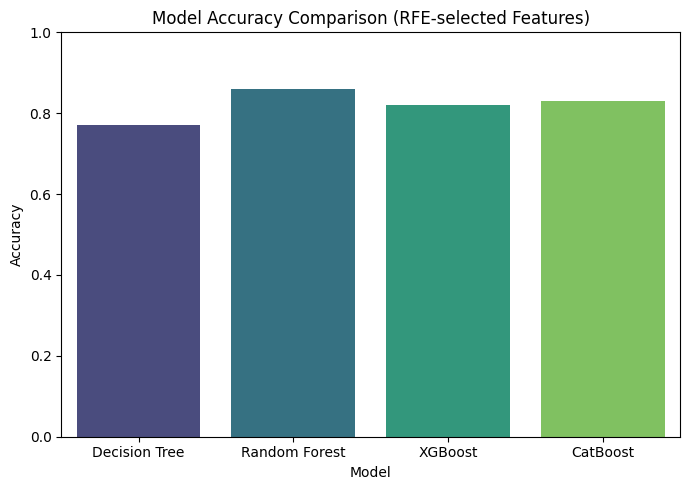

In [ ]:
# --- Model Accuracy Comparison ---
if 'acc_df' in globals():
    print("\n===== MODEL PERFORMANCE ANALYSIS (RFE-selected features) =====\n")
    print(acc_df)

    plt.figure(figsize=(7, 5))
    sns.barplot(x='Model', y='Accuracy', data=acc_df, palette='viridis')
    plt.title("Model Accuracy Comparison (RFE-selected Features)")
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

else:
    print("\n[Note] acc_df (accuracy table) not found in this session. Skipping accuracy plots.")



===== STABILITY ANALYSIS =====
                                     Feature  Mean Selection (0-1)  \
0                      Adjustment_Difficulty                  1.00   
1                      Classmate_Cooperation                  1.00   
2                           Father_Education                  1.00   
3                  Relationship_Satisfaction                  1.00   
4                             Overall_Health                  1.00   
5                 Program_Satisfaction_Level                  1.00   
6                             Mentor_Support                  0.75   
7                           Motivation_Level                  0.75   
8                       Family_Relationships                  0.75   
9                                        Age                  0.75   
10                              Average_CGPA                  0.75   
11                                 Free_Time                  0.75   
12                              Travel_Time_              

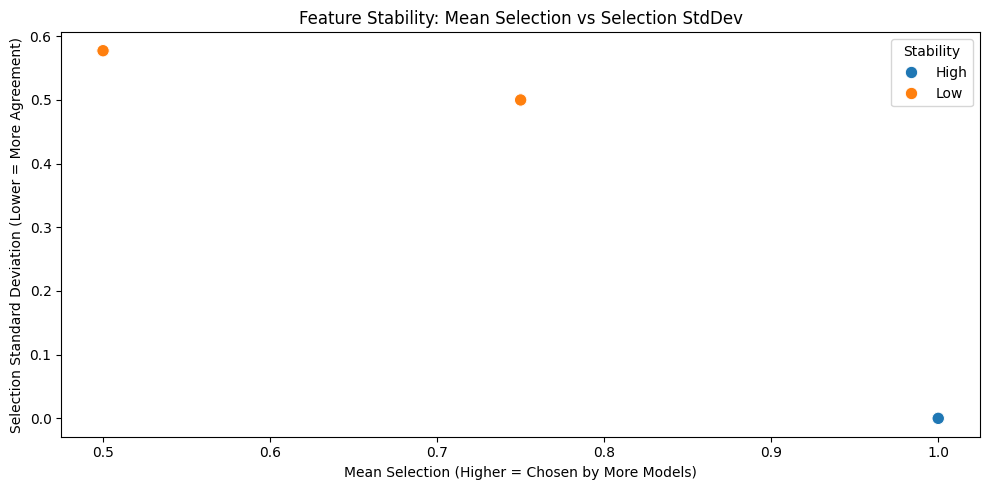

In [ ]:
# --- Stability Analysis Plot ---
print("\n===== STABILITY ANALYSIS =====")
rank_summary['Stability'] = np.where(rank_summary['Selection StdDev'] <= 0.25, 'High', 'Low')
print(rank_summary.head(20))

plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=rank_summary.head(20),
    x='Mean Selection (0-1)', y='Selection StdDev',
    hue='Stability', s=80
)
plt.title("Feature Stability: Mean Selection vs Selection StdDev")
plt.xlabel("Mean Selection (Higher = Chosen by More Models)")
plt.ylabel("Selection Standard Deviation (Lower = More Agreement)")
plt.tight_layout()
plt.show()
